# DST and Crime Analysis
## Arizona (Control) vs California and Florida (Treated), 2022-2024

This notebook estimates the effect of Daylight Saving Time on daily crime rates using a difference-in-differences design. Arizona does not observe DST, so it serves as the control group. California and Florida observe DST and are the treated group.

- Outcomes: daily crime rates per 100,000 residents for selected offense types (auto-detected from the panel)
- Panel: 2022-2024, all county-days filled in (zeros for days with no reported incidents)
- Standard errors clustered at the county level

In [36]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('colorblind')

ROOT = Path('..').resolve()
PANEL_PATH = ROOT / 'data/processed/model/focus_states_daily_county_model_panel_2022_2024.csv'

print('Root:', ROOT)
print('Panel exists:', PANEL_PATH.exists())

Root: C:\Users\LENOVO\Desktop\Duke\Semester 2\IDS 701 - Problem Solving with Data Science\Final UDS\IDS701_UDS_Final_Project
Panel exists: True


## 1. Load and Validate

In [37]:
raw = pd.read_csv(PANEL_PATH, low_memory=False, parse_dates=['incident_date'])

print(f'Panel shape: {raw.shape}')
print(f'Date range: {raw["incident_date"].min().date()} to {raw["incident_date"].max().date()}')
print(f'Crime types: {sorted(raw["crime_type"].unique())}')
print(f'States:      {sorted(raw["state"].unique())}')

# Key integrity checks
dup = raw.duplicated(['state','county_fips','incident_date','crime_type']).sum()
zero_share = (raw['incident_count'] == 0).mean()
tz_ok = raw['timezone'].isin(['America/Los_Angeles','America/Chicago','America/New_York',
                               'America/Phoenix','America/Denver']).all()

print(f'\nIntegrity checks:')
print(f'  Duplicate keys:       {dup}  (should be 0)')
print(f'  Zero-incident share:  {zero_share:.4f}  (should be ~0.67)')
print(f'  All timezones valid:  {tz_ok}')
print(f'  Missing population:   {raw["population"].isna().sum()}')
print(f'  Missing income:       {raw["median_household_income"].isna().sum()}')

Panel shape: (920640, 28)
Date range: 2022-01-01 to 2024-12-31
Crime types: ['burglary', 'motor_vehicle_theft', 'robbery', 'shoplifting', 'theft_from_building', 'theft_from_motor_vehicle']
States:      ['AZ', 'CA', 'FL']

Integrity checks:
  Duplicate keys:       0  (should be 0)
  Zero-incident share:  0.7027  (should be ~0.67)
  All timezones valid:  True
  Missing population:   0
  Missing income:       0


## 2. Estimation Sample

Treated group: CA and FL counties that observe DST.
Control group: AZ counties on America/Phoenix time (no DST).

Three AZ counties in Navajo Nation territory observe DST and are excluded from the control group.

In [38]:
# Build estimation sample
treated_mask  = raw['treated_state'] & raw['observes_dst_county']
control_mask  = raw['is_az_control'] & ~raw['observes_dst_county']
sample = raw[treated_mask | control_mask].copy()

# Year-month time FE identifier
sample['year_month'] = sample['incident_date'].dt.to_period('M').astype(str)
sample['year_week']  = sample['incident_date'].dt.to_period('W').astype(str)
sample['data_year']  = sample['incident_date'].dt.year

# Log outcome (for robustness)
sample['log_rate'] = np.log1p(sample['crime_rate_per_100k'])

# Treatment group labels for plots
sample['group'] = sample['state'].map({'CA': 'California (treated)',
                                       'FL': 'Florida (treated)',
                                       'AZ': 'Arizona (control)'})

# Preferred offense types (will use those present in data)
preferred_crime_types = [
    'burglary',
    'motor_vehicle_theft',
    'theft_from_motor_vehicle',
    'robbery',
    'theft_from_building',
    'shoplifting',
]
available_crime_types = sorted(sample['crime_type'].dropna().unique().tolist())
crime_types = [ct for ct in preferred_crime_types if ct in available_crime_types]
missing_preferred = [ct for ct in preferred_crime_types if ct not in available_crime_types]

# Pretty labels for plots/tables
titles = {
    'burglary': 'Burglary',
    'motor_vehicle_theft': 'Motor Vehicle Theft',
    'theft_from_motor_vehicle': 'Theft From Motor Vehicle',
    'robbery': 'Robbery',
    'theft_from_building': 'Theft From Building',
    'shoplifting': 'Shoplifting',
}

# Summary
county_counts = sample.drop_duplicates(['state','county_fips']).groupby('state').size()
print('Counties in estimation sample:')
print(county_counts.rename('n_counties').to_frame())
print(f'\nTotal rows: {len(sample):,}')
print(f'Crime types used in notebook: {crime_types}')
if missing_preferred:
    print(f'Not yet available in panel: {missing_preferred}')
print(f'Excluded (AZ Navajo): {len(raw) - len(sample) - (len(raw[~(treated_mask|control_mask)]) - len(raw[raw["is_az_control"] & raw["observes_dst_county"]])):,} rows (3 AZ Denver counties)')

Counties in estimation sample:
       n_counties
state            
AZ             12
CA             58
FL             67

Total rows: 900,912
Crime types used in notebook: ['burglary', 'motor_vehicle_theft', 'theft_from_motor_vehicle', 'robbery', 'theft_from_building', 'shoplifting']
Excluded (AZ Navajo): 19,728 rows (3 AZ Denver counties)


## 3. Descriptive Statistics

In [39]:
# Summary stats by state - crime type
desc = (
    sample
    .groupby(['state','crime_type'])
    .agg(
        n_county_days=('incident_count','count'),
        mean_incidents=('incident_count','mean'),
        zero_days_pct=('incident_count', lambda x: (x==0).mean()*100),
        mean_rate_per100k=('crime_rate_per_100k','mean'),
        median_rate_per100k=('crime_rate_per_100k','median'),
        p95_rate=('crime_rate_per_100k', lambda x: x.quantile(0.95))
    )
    .reset_index()
)
print('Descriptive statistics by state - crime type')
print(desc.to_string(index=False))

Descriptive statistics by state - crime type
state               crime_type  n_county_days  mean_incidents  zero_days_pct  mean_rate_per100k  median_rate_per100k  p95_rate
   AZ                 burglary          13152          2.0327        52.3418             0.4090               0.0000    1.7873
   AZ      motor_vehicle_theft          13152          1.9316        59.6183             0.2866               0.0000    1.2035
   AZ                  robbery          13152          0.3260        85.0441             0.0307               0.0000    0.1852
   AZ              shoplifting          13152          5.0751        47.6658             0.6512               0.3892    2.6493
   AZ      theft_from_building          13152          0.9195        75.4106             0.1224               0.0000    0.4641
   AZ theft_from_motor_vehicle          13152          2.2910        65.9063             0.2191               0.0000    0.8593
   CA                 burglary          63568          3.0762     

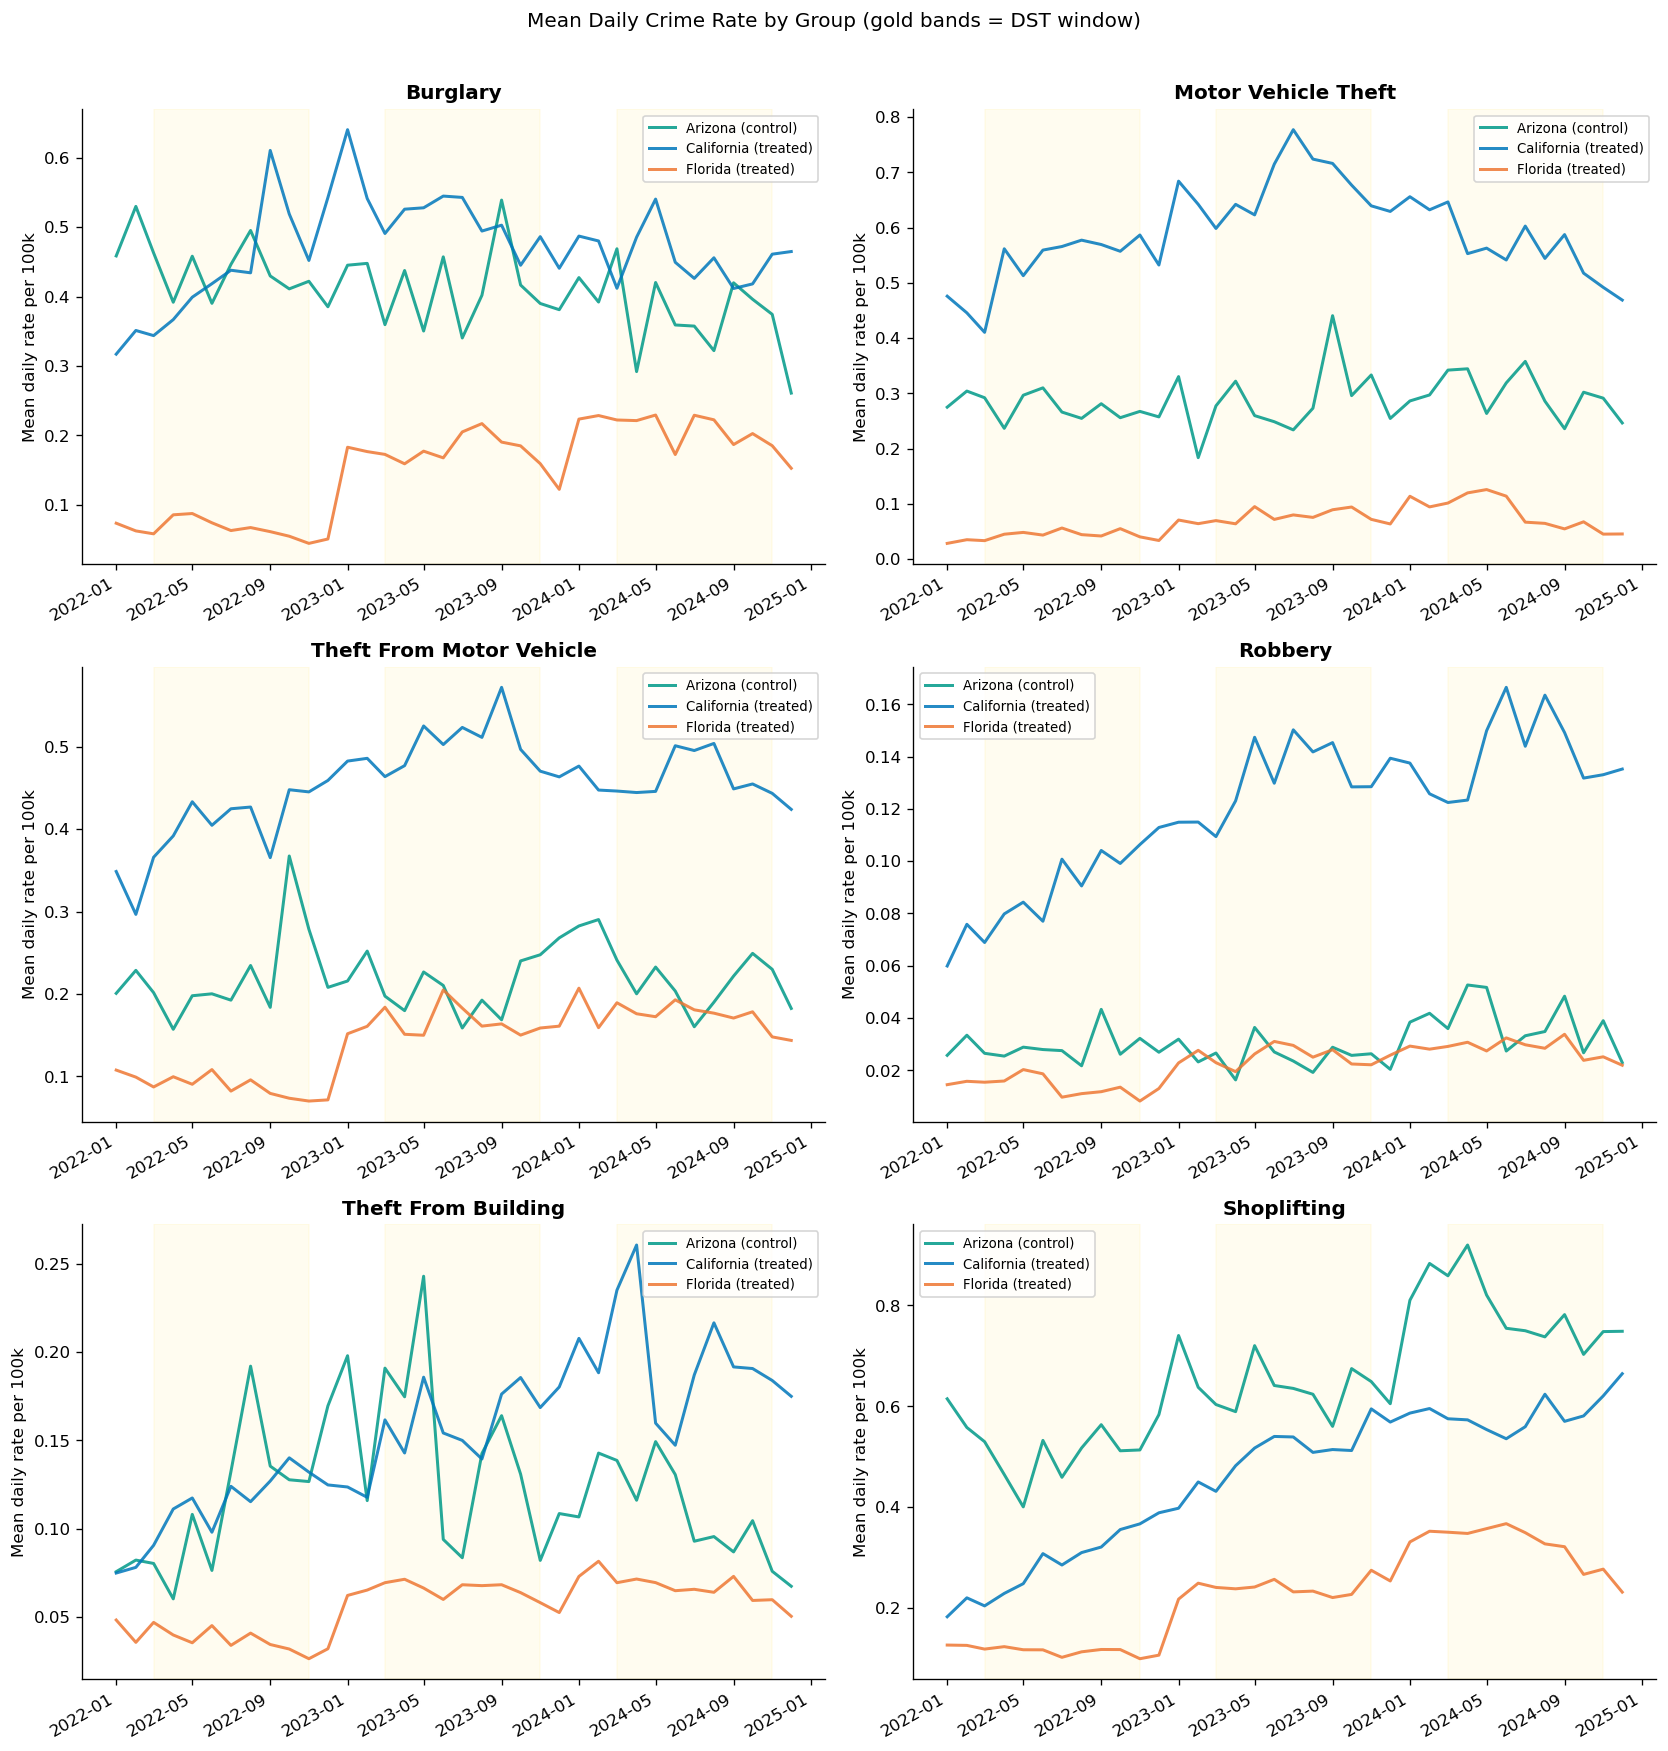

In [40]:
# Monthly crime rate trends by group - crime type
monthly = (
    sample
    .groupby(['group', 'year_month', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'),
         in_dst=('in_dst_window','mean'))
)
monthly['date'] = pd.to_datetime(monthly['year_month'])

colors = {'California (treated)': '#0077BB', 'Florida (treated)': '#EE7733', 'Arizona (control)': '#009988'}

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows), sharey=False)
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    ax = axes[i]
    sub = monthly[monthly['crime_type'] == ct]
    for grp, gdf in sub.groupby('group'):
        ax.plot(gdf['date'], gdf['mean_rate'], label=grp,
                color=colors[grp], lw=1.8, alpha=0.85)

    # Shade DST windows (approximate: March-November each year)
    for yr in [2022, 2023, 2024]:
        dst_start = pd.Timestamp(f'{yr}-03-01')
        dst_end   = pd.Timestamp(f'{yr}-11-01')
        ax.axvspan(dst_start, dst_end, alpha=0.06, color='gold', zorder=0)

    ax.set_title(titles.get(ct, ct.replace('_', ' ').title()), fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean daily rate per 100k')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Hide unused axes if odd number of crime types
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Mean Daily Crime Rate by Group (gold bands = DST window)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

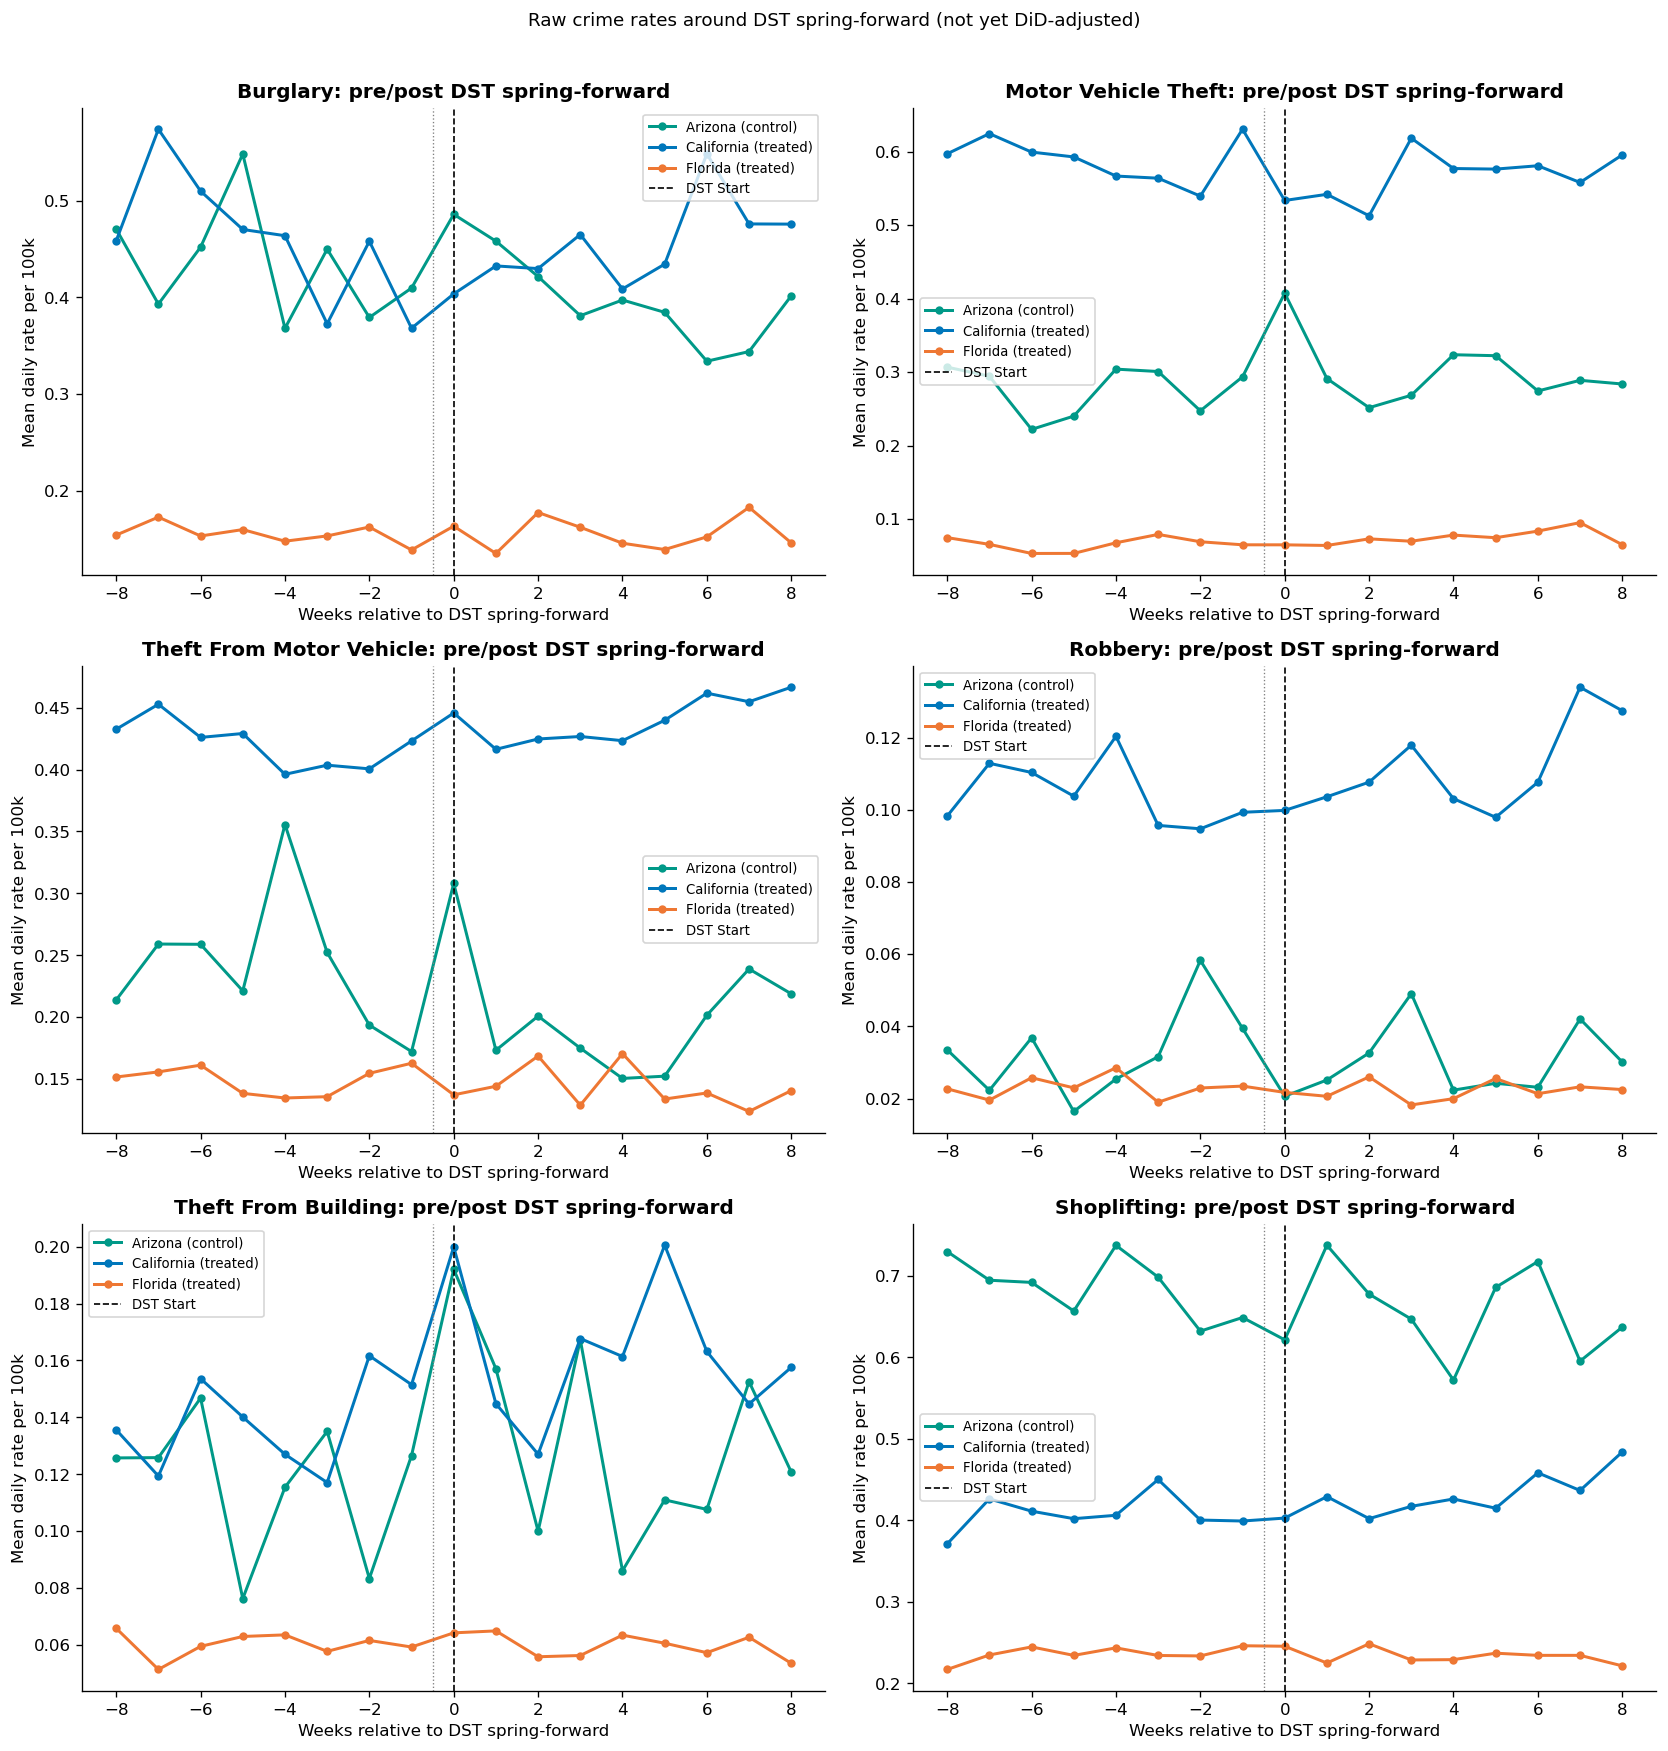

In [41]:
# Pre-trends visual: plot crime rates by week-of-year relative to DST start
# using only 8 weeks before and after spring-forward
pre_post = sample.copy()
pre_post['week_from_start'] = (pre_post['days_from_dst_start'] // 7).clip(-8, 8)

pre_post_agg = (
    pre_post
    .groupby(['group', 'week_from_start', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'))
)

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    ax = axes[i]
    sub = pre_post_agg[pre_post_agg['crime_type'] == ct]
    for grp, gdf in sub.groupby('group'):
        ax.plot(gdf['week_from_start'], gdf['mean_rate'],
                marker='o', ms=4, label=grp, color=colors[grp], lw=1.8)
    ax.axvline(0, color='black', ls='--', lw=1, label='DST Start')
    ax.axvline(-0.5, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Weeks relative to DST spring-forward')
    ax.set_ylabel('Mean daily rate per 100k')
    ax.set_title(f"{titles.get(ct, ct.replace('_', ' ').title())}: pre/post DST spring-forward", fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Raw crime rates around DST spring-forward (not yet DiD-adjusted)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 4. Two-Way Fixed Effects DiD

The main specification regresses daily crime rate on a DST-window indicator, controlling for county fixed effects and year-month fixed effects. Weekend and holiday indicators are included as additional controls.

The treatment variable (in_dst_window) equals 1 for CA/FL counties during the DST calendar window (mid-March through early November) and 0 for AZ counties year-round. After absorbing county and time fixed effects, the coefficient captures how crime in CA/FL shifts during DST months relative to AZ.

Estimated via sequential within-transformation: demean by county, then by year-month. Standard errors clustered at the county level.

In [42]:
def run_twfe(df, outcome, regressors,
             entity='county_fips', time='year_month', cluster='county_fips'):
    """
    Two-way fixed effects OLS via sequential within-transformation (FWL theorem).
    Valid for balanced or near-balanced panels.
    Returns a statsmodels RegressionResultsWrapper with clustered SEs.
    """
    # Deduplicate cols: entity and cluster are often the same column
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d = df[cols].dropna(subset=[outcome]).copy()

    for c in [outcome] + regressors:
        d[c] = d[c].astype(float)

    # Remove entity (county) FE
    e_means = d.groupby(entity)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - e_means

    # Remove time FE (on entity-demeaned data)
    t_means = d.groupby(time)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - t_means

    X = sm.add_constant(d[regressors])
    groups = df.loc[d.index, cluster].values
    result = sm.OLS(d[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )
    return result


def twfe_table(results_dict):
    """Format a multi-column results table from a dict of (label -> result)."""
    rows = []
    for label, res in results_dict.items():
        coef = res.params.get('in_dst_window', float('nan'))
        se   = res.bse.get('in_dst_window', float('nan'))
        pval = res.pvalues.get('in_dst_window', float('nan'))
        if 'in_dst_window' in res.params.index:
            ci_lo, ci_hi = res.conf_int().loc['in_dst_window']
        else:
            ci_lo = ci_hi = float('nan')
        stars = ('***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else '')
        rows.append({
            'Specification': label,
            'beta(InDSTWindow)': f'{coef:.4f}{stars}',
            'SE (cluster)': f'({se:.4f})',
            'p-value': f'{pval:.3f}',
            '95% CI': f'[{ci_lo:.4f}, {ci_hi:.4f}]',
            'N (obs)': f'{int(res.nobs):,}',
            'R2 (within)': f'{res.rsquared:.4f}'
        })
    return pd.DataFrame(rows)

print('Functions defined.')


Functions defined.


In [43]:
# Run TWFE for each crime type (full sample, then treated-only placebo)
base_controls = ['in_dst_window', 'is_weekend', 'is_holiday']
socio_controls = base_controls + ['median_household_income', 'poverty_rate',
                                   'unemployment_rate', 'bachelors_plus_rate']

results = {}

for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()

    # (1) Baseline: rate ~ in_dst_window + county FE + year_month FE + weekend + holiday
    results[f'{ct} | rate | baseline'] = run_twfe(
        sub, 'crime_rate_per_100k', base_controls
    )

    # (2) With socioeconomic controls
    results[f'{ct} | rate | + socio'] = run_twfe(
        sub, 'crime_rate_per_100k', socio_controls
    )

    # (3) Log outcome
    results[f'{ct} | log(rate) | baseline'] = run_twfe(
        sub, 'log_rate', base_controls
    )

print('Estimation complete.')
print(twfe_table(results).to_string(index=False))

Estimation complete.
                                  Specification beta(InDSTWindow) SE (cluster) p-value             95% CI N (obs) R2 (within)
                     burglary | rate | baseline           0.0171*     (0.0097)   0.076  [-0.0018, 0.0361] 150,152      0.0002
                      burglary | rate | + socio           0.0172*     (0.0097)   0.076  [-0.0018, 0.0361] 150,152      0.0007
                burglary | log(rate) | baseline            0.0055     (0.0038)   0.148  [-0.0019, 0.0129] 150,152      0.0005
          motor_vehicle_theft | rate | baseline           -0.0154     (0.0124)   0.215  [-0.0398, 0.0089] 150,152      0.0001
           motor_vehicle_theft | rate | + socio           -0.0154     (0.0124)   0.215  [-0.0398, 0.0090] 150,152      0.0006
     motor_vehicle_theft | log(rate) | baseline           -0.0025     (0.0031)   0.426  [-0.0085, 0.0036] 150,152      0.0001
     theft_from_motor_vehicle | rate | baseline           0.0160*     (0.0089)   0.073  [-0.0015,

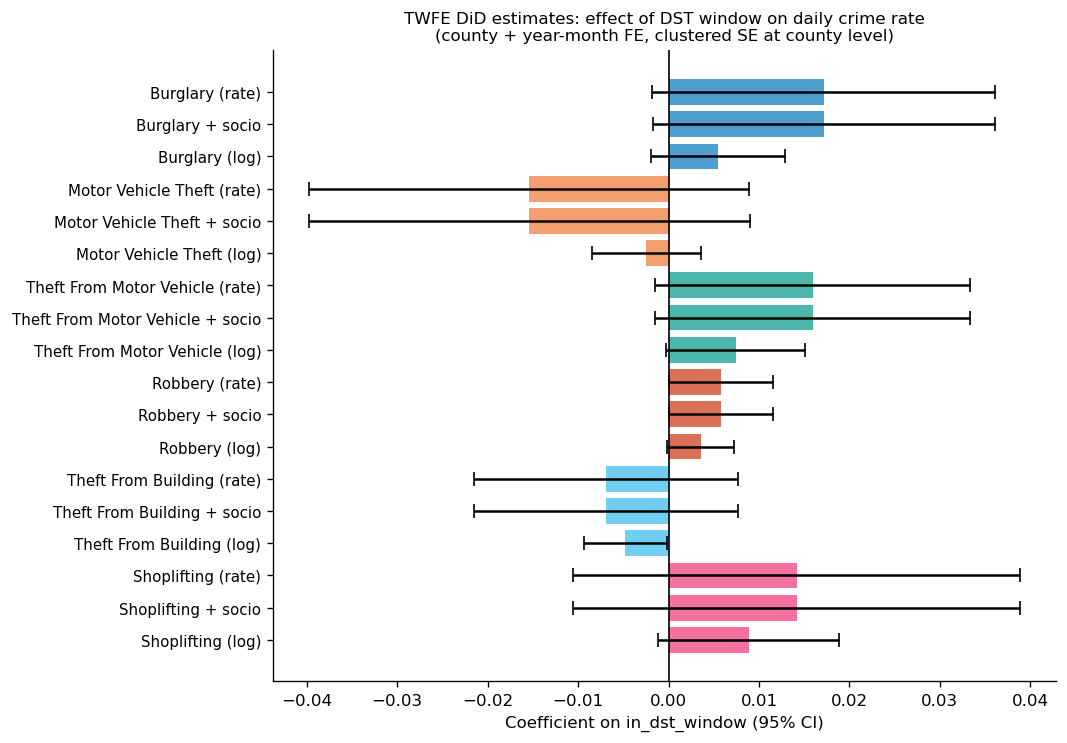

In [44]:
# Coefficient plot: baseline estimates with 95% CIs
plot_specs = []
for ct in crime_types:
    plot_specs.extend([
        (f'{ct} | rate | baseline',      f"{titles.get(ct, ct.replace('_',' ').title())} (rate)"),
        (f'{ct} | rate | + socio',       f"{titles.get(ct, ct.replace('_',' ').title())} + socio"),
        (f'{ct} | log(rate) | baseline', f"{titles.get(ct, ct.replace('_',' ').title())} (log)"),
    ])

coefs, ses, labels = [], [], []
for key, lbl in plot_specs:
    if key not in results:
        continue
    r = results[key]
    coefs.append(r.params['in_dst_window'])
    ses.append(r.bse['in_dst_window'])
    labels.append(lbl)

coefs = np.array(coefs)
ses   = np.array(ses)
ci95  = 1.96 * ses

fig_h = max(5, 0.35 * len(labels))
fig, ax = plt.subplots(figsize=(9, fig_h))
y_pos = np.arange(len(labels))[::-1]

# Alternate colors by crime type block
colors_cycle = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377']
colors_bar = [colors_cycle[(i // 3) % len(colors_cycle)] for i in range(len(labels))]

ax.barh(y_pos, coefs, xerr=ci95, color=colors_bar, alpha=0.7,
        error_kw={'elinewidth': 1.5, 'capsize': 4})
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Coefficient on in_dst_window (95% CI)')
ax.set_title('TWFE DiD estimates: effect of DST window on daily crime rate\n'
             '(county + year-month FE, clustered SE at county level)', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Event Study

Checks whether CA/FL and AZ were trending similarly before the DST transition, and traces how the gap evolves around it.

Week bins are formed as floor(days_from_dst_start / 7), clipped to [-8, +8]. The week before spring-forward (week -1) is the reference. Year fixed effects are used here instead of year-month, so the within-year weekly pattern is not absorbed. Flat pre-period coefficients support the parallel trends assumption.

In [45]:
def run_event_study(df, outcome, entity='county_fips', time='data_year',
                    cluster='county_fips', clip=(-8, 8), ref_bin=-1):
    """
    Dynamic DiD event study around DST spring-forward.
    Returns DataFrame of (week_bin, coef, se, ci_lo, ci_hi).
    """
    d = df.copy()
    d['week_rel'] = (d['days_from_dst_start'] // 7).clip(*clip)
    bins = [b for b in sorted(d['week_rel'].unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f'tw_{b:+d}'
        d[col] = d['treated_state'].astype(float) * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()

    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'week': b, 'coef': res.params[col],
                         'se': res.bse[col], 'pval': res.pvalues[col],
                         'ci_lo': ci[0], 'ci_hi': ci[1]})
    rows.append({'week': ref_bin, 'coef': 0, 'se': 0, 'pval': 1, 'ci_lo': 0, 'ci_hi': 0})
    return pd.DataFrame(rows).sort_values('week').reset_index(drop=True)


def plot_event_study(es_df, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(es_df['week'], es_df['ci_lo'], es_df['ci_hi'],
                    alpha=0.18, color='steelblue')
    ax.plot(es_df['week'], es_df['coef'], 'o-', color='steelblue', ms=5, lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(-0.5, color='crimson', ls='--', lw=1.2, label='DST spring-forward')
    ax.axvspan(-8, -0.5, alpha=0.04, color='green', label='Pre-period')
    ax.axvspan(-0.5, 8, alpha=0.04, color='gold', label='Post (DST active)')
    ax.set_xlabel('Weeks relative to DST spring-forward')
    ax.set_ylabel('beta_k (treated vs AZ, relative to week -1)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    return ax

print('Event study functions defined.')


Event study functions defined.


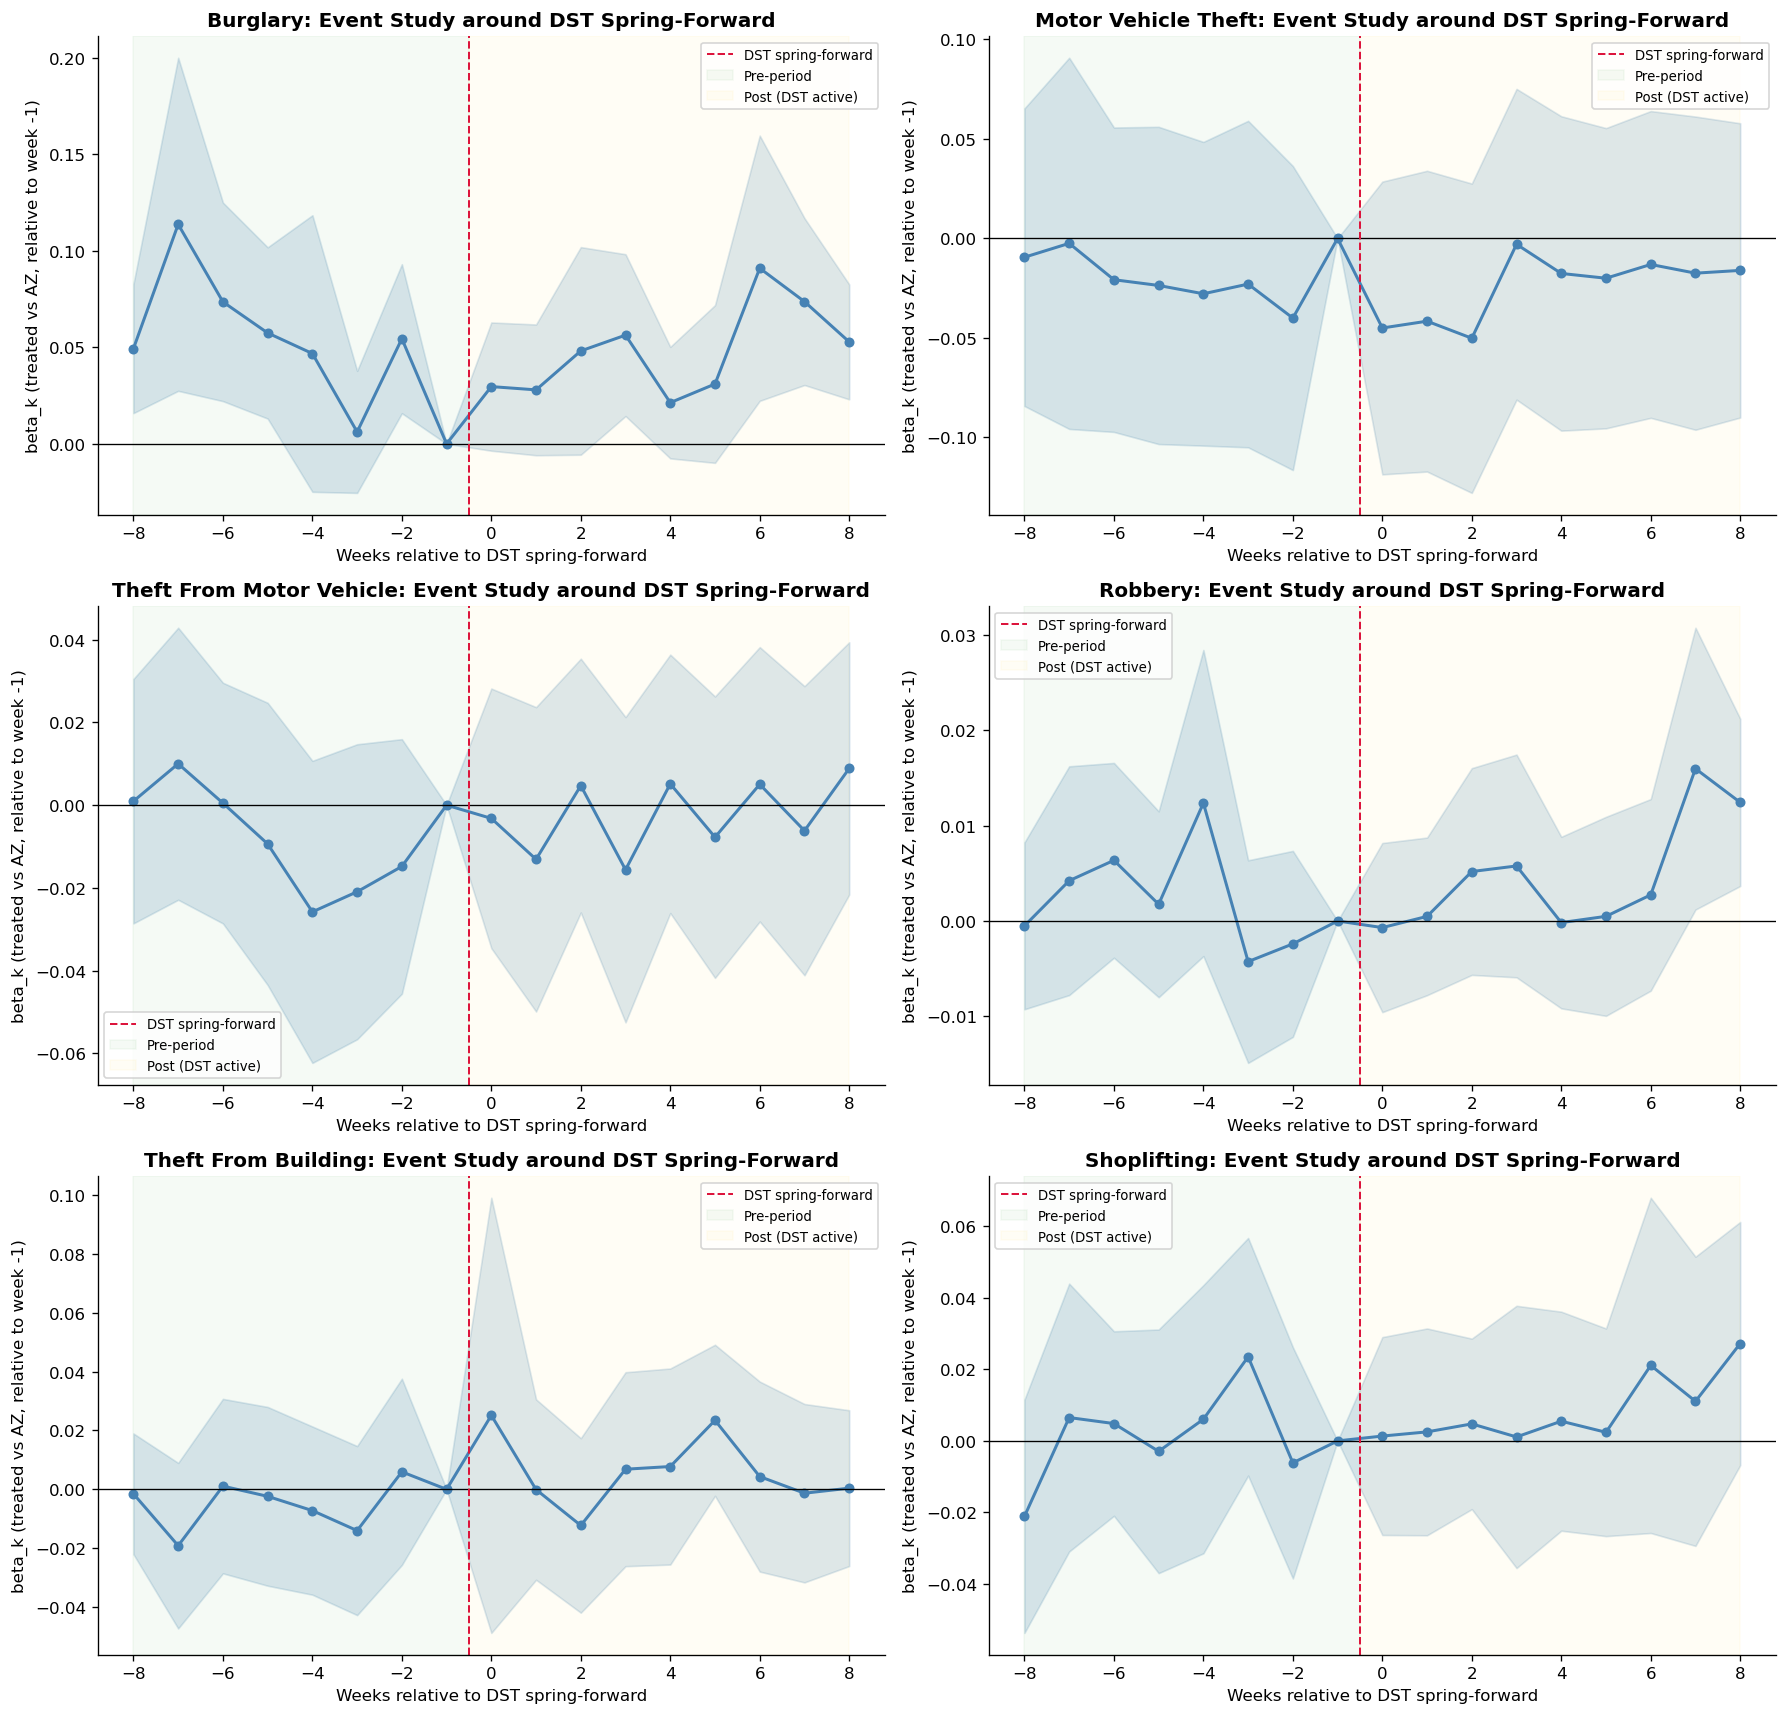


Pre-trend test (weeks -8 to -2): p-values should be large
  Burglary: 5/7 pre-treatment bins significant at 10%
  Motor Vehicle Theft: 0/7 pre-treatment bins significant at 10%
  Theft From Motor Vehicle: 0/7 pre-treatment bins significant at 10%
  Robbery: 0/7 pre-treatment bins significant at 10%
  Theft From Building: 0/7 pre-treatment bins significant at 10%
  Shoplifting: 0/7 pre-treatment bins significant at 10%


In [46]:
# Event study: spring-forward
es_results = {}
for ct in crime_types:
    es_results[ct] = run_event_study(
        sample[sample['crime_type'] == ct],
        'crime_rate_per_100k'
    )

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    plot_event_study(es_results[ct], f"{titles.get(ct, ct.replace('_',' ').title())}: Event Study around DST Spring-Forward", ax=axes[i])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print('\nPre-trend test (weeks -8 to -2): p-values should be large')
for ct in crime_types:
    es_df = es_results[ct]
    pre = es_df[es_df['week'] <= -2]
    sig = (pre['pval'] < 0.1).sum()
    print(f"  {titles.get(ct, ct)}: {sig}/{len(pre)} pre-treatment bins significant at 10%")

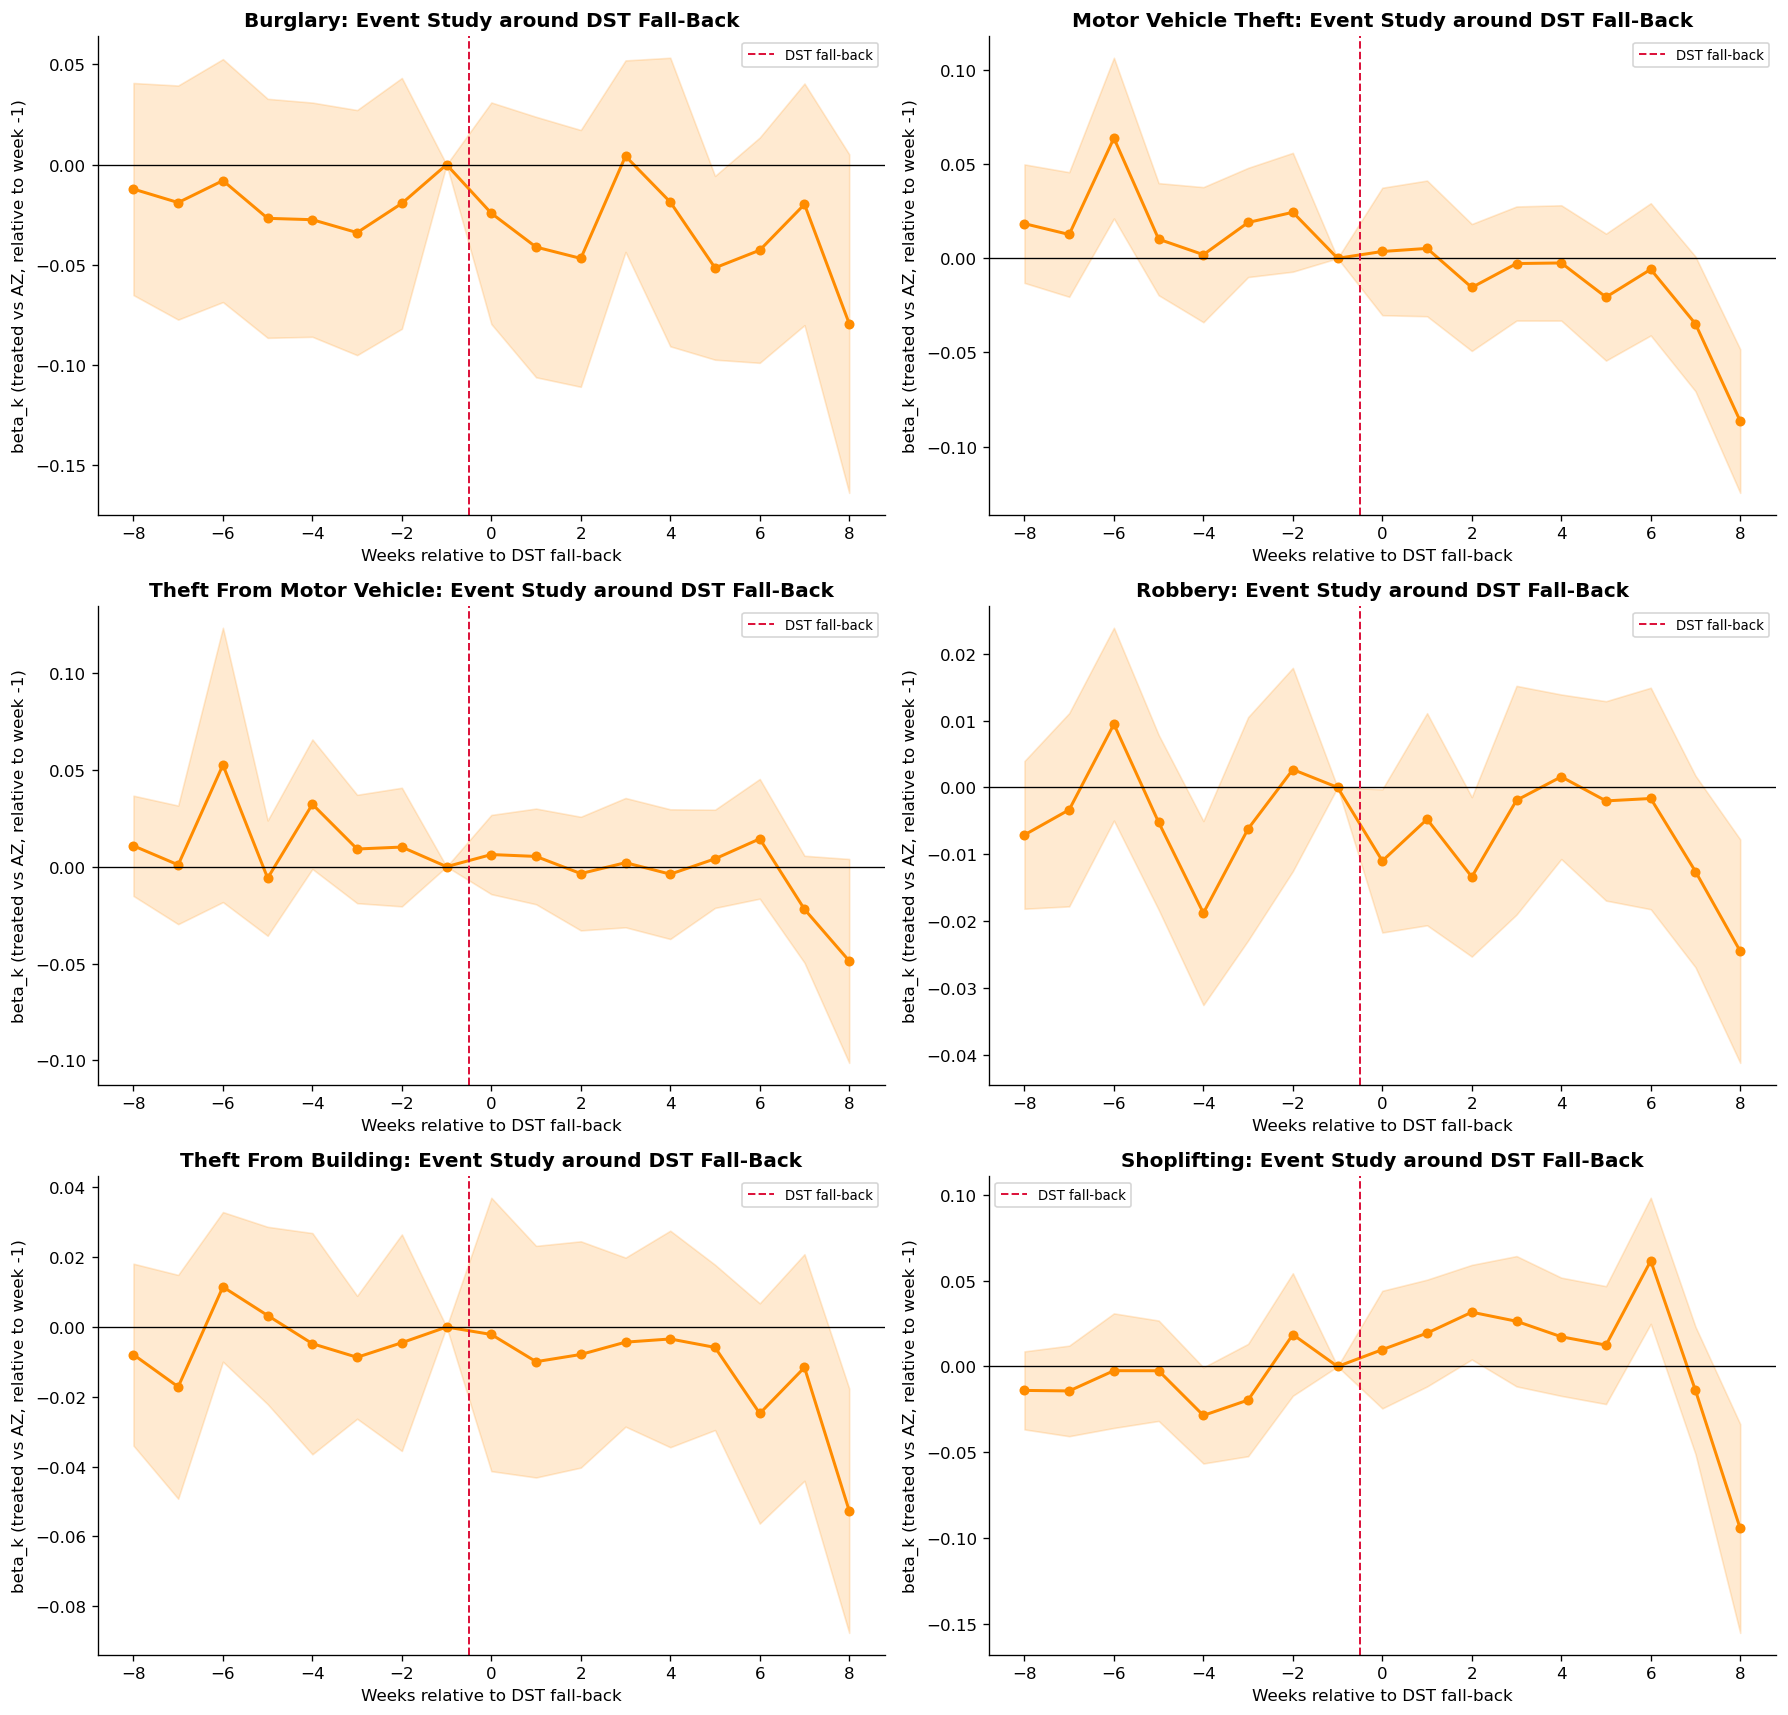

In [47]:
# Event study: fall-back (around DST end)
def run_event_study_end(df, outcome, entity='county_fips', time='data_year',
                        cluster='county_fips', clip=(-8, 8), ref_bin=-1):
    d = df.copy()
    d['week_rel'] = (d['days_from_dst_end'] // 7).clip(*clip)
    bins = [b for b in sorted(d['week_rel'].unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f'twe_{b:+d}'
        d[col] = d['treated_state'].astype(float) * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'week': b, 'coef': res.params[col],
                         'se': res.bse[col], 'pval': res.pvalues[col],
                         'ci_lo': ci[0], 'ci_hi': ci[1]})
    rows.append({'week': ref_bin, 'coef': 0, 'se': 0, 'pval': 1, 'ci_lo': 0, 'ci_hi': 0})
    return pd.DataFrame(rows).sort_values('week').reset_index(drop=True)


es_end_results = {}
for ct in crime_types:
    es_end_results[ct] = run_event_study_end(sample[sample['crime_type'] == ct], 'crime_rate_per_100k')

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for i, ct in enumerate(crime_types):
    ax = axes[i]
    es_df = es_end_results[ct]
    ax.fill_between(es_df['week'], es_df['ci_lo'], es_df['ci_hi'], alpha=0.18, color='darkorange')
    ax.plot(es_df['week'], es_df['coef'], 'o-', color='darkorange', ms=5, lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(-0.5, color='crimson', ls='--', lw=1.2, label='DST fall-back')
    ax.set_xlabel('Weeks relative to DST fall-back')
    ax.set_ylabel('beta_k (treated vs AZ, relative to week -1)')
    ax.set_title(f"{titles.get(ct, ct.replace('_',' ').title())}: Event Study around DST Fall-Back", fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 6. Narrow-Window Check

A tighter test: restricting to observations within 7, 14, or 21 days of the spring-forward date and comparing the days just before vs. just after. This trades sample size for tighter control over confounders that change slowly across the year.

In [48]:
def run_rd(df, outcome, window_days, entity='county_fips', time='data_year', cluster='county_fips'):
    """Narrow-window DiD around DST spring-forward. Treatment = in_dst_window within window."""
    d = df[abs(df['days_from_dst_start']) <= window_days].copy()
    regressors = ['in_dst_window', 'is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(
        cov_type='cluster', cov_kwds={'groups': groups}
    )
    return res, len(d2)


rd_results = {}
for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()
    for window in [7, 14, 21]:
        res, n = run_rd(sub, 'crime_rate_per_100k', window)
        rd_results[f'{ct} | +-{window}d'] = (res, n)

rows = []
for label, (res, n) in rd_results.items():
    coef = res.params.get('in_dst_window', float('nan'))
    se   = res.bse.get('in_dst_window', float('nan'))
    pval = res.pvalues.get('in_dst_window', float('nan'))
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    rows.append({'Window': label, 'beta': f'{coef:.4f}{stars}',
                 'SE': f'({se:.4f})', 'p': f'{pval:.3f}', 'N obs': f'{n:,}'})

print('Narrow-window RD estimates (county + year FE, clustered SE):')
print(pd.DataFrame(rows).to_string(index=False))


Narrow-window RD estimates (county + year FE, clustered SE):
                          Window    beta       SE     p  N obs
                 burglary | +-7d  0.0241 (0.0160) 0.132  6,165
                burglary | +-14d  0.0079 (0.0130) 0.542 11,919
                burglary | +-21d  0.0170 (0.0120) 0.154 17,673
      motor_vehicle_theft | +-7d -0.0392 (0.0357) 0.272  6,165
     motor_vehicle_theft | +-14d -0.0239 (0.0197) 0.223 11,919
     motor_vehicle_theft | +-21d -0.0238 (0.0180) 0.185 17,673
 theft_from_motor_vehicle | +-7d -0.0034 (0.0153) 0.822  6,165
theft_from_motor_vehicle | +-14d -0.0013 (0.0116) 0.907 11,919
theft_from_motor_vehicle | +-21d  0.0082 (0.0093) 0.378 17,673
                  robbery | +-7d -0.0005 (0.0045) 0.904  6,165
                 robbery | +-14d  0.0008 (0.0032) 0.809 11,919
                 robbery | +-21d  0.0033 (0.0029) 0.256 17,673
      theft_from_building | +-7d  0.0167 (0.0311) 0.592  6,165
     theft_from_building | +-14d  0.0055 (0.0177) 0.755 1

## 7. Heterogeneity

In [49]:
# By state: estimate separately for CA, FL, and AZ vs CA, AZ vs FL
het_results = {}

for ct in crime_types:
    # CA only vs AZ control
    sub_ca = sample[(sample['crime_type'] == ct) &
                    ((sample['state'] == 'CA') | (sample['state'] == 'AZ'))].copy()
    het_results[f'{ct} | CA vs AZ'] = run_twfe(sub_ca, 'crime_rate_per_100k', base_controls)

    # FL only vs AZ control
    sub_fl = sample[(sample['crime_type'] == ct) &
                    ((sample['state'] == 'FL') | (sample['state'] == 'AZ'))].copy()
    het_results[f'{ct} | FL vs AZ'] = run_twfe(sub_fl, 'crime_rate_per_100k', base_controls)

    # FL Panhandle (Central Time) vs FL Eastern vs AZ
    sub_fl_e = sample[(sample['crime_type'] == ct) &
                      ((sample['state'] == 'AZ') |
                       ((sample['state'] == 'FL') & (sample['timezone'] == 'America/New_York')))].copy()
    het_results[f'{ct} | FL-Eastern vs AZ'] = run_twfe(sub_fl_e, 'crime_rate_per_100k', base_controls)

    sub_fl_c = sample[(sample['crime_type'] == ct) &
                      ((sample['state'] == 'AZ') |
                       ((sample['state'] == 'FL') & (sample['timezone'] == 'America/Chicago')))].copy()
    het_results[f'{ct} | FL-Panhandle vs AZ'] = run_twfe(sub_fl_c, 'crime_rate_per_100k', base_controls)

print('Heterogeneity by state/subgroup:')
print(twfe_table(het_results).to_string(index=False))

Heterogeneity by state/subgroup:
                                Specification beta(InDSTWindow) SE (cluster) p-value            95% CI N (obs) R2 (within)
                          burglary | CA vs AZ            0.0125     (0.0145)   0.390 [-0.0160, 0.0409]  76,720      0.0002
                          burglary | FL vs AZ            0.0186     (0.0113)   0.102 [-0.0037, 0.0408]  86,584      0.0003
                  burglary | FL-Eastern vs AZ            0.0177     (0.0122)   0.146 [-0.0062, 0.0416]  75,624      0.0003
                burglary | FL-Panhandle vs AZ            0.0172     (0.0205)   0.401 [-0.0230, 0.0574]  24,112      0.0006
               motor_vehicle_theft | CA vs AZ           -0.0171     (0.0205)   0.403 [-0.0573, 0.0230]  76,720      0.0002
               motor_vehicle_theft | FL vs AZ           -0.0016     (0.0049)   0.739 [-0.0113, 0.0080]  86,584      0.0000
       motor_vehicle_theft | FL-Eastern vs AZ           -0.0009     (0.0054)   0.874 [-0.0115, 0.0098]  75

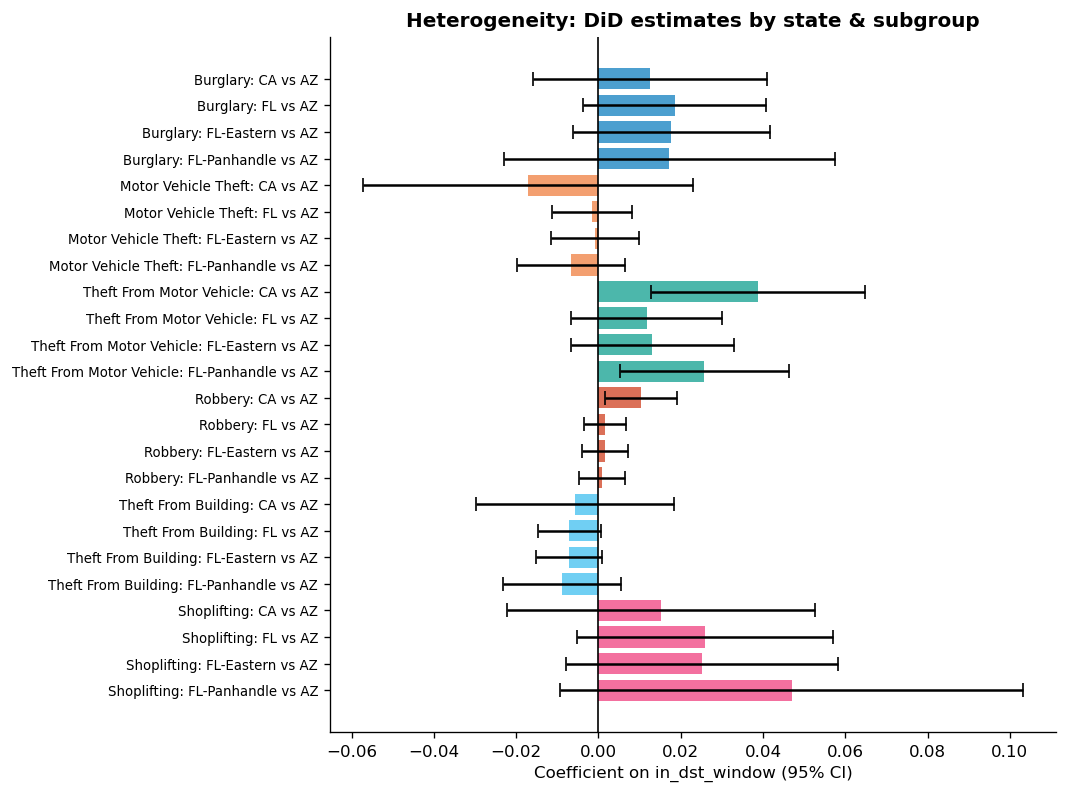

In [50]:
# Forest plot: heterogeneity
het_plot_specs = []
for ct in crime_types:
    label_base = titles.get(ct, ct.replace('_', ' ').title())
    het_plot_specs.extend([
        (f'{ct} | CA vs AZ',           f'{label_base}: CA vs AZ'),
        (f'{ct} | FL vs AZ',           f'{label_base}: FL vs AZ'),
        (f'{ct} | FL-Eastern vs AZ',   f'{label_base}: FL-Eastern vs AZ'),
        (f'{ct} | FL-Panhandle vs AZ', f'{label_base}: FL-Panhandle vs AZ'),
    ])

coefs2, ses2, labels2 = [], [], []
for key, lbl in het_plot_specs:
    if key not in het_results:
        continue
    r = het_results[key]
    coefs2.append(r.params['in_dst_window'])
    ses2.append(r.bse['in_dst_window'])
    labels2.append(lbl)

coefs2 = np.array(coefs2)
ci95_2 = 1.96 * np.array(ses2)

fig_h = max(6, 0.28 * len(labels2))
fig, ax = plt.subplots(figsize=(9, fig_h))
y_pos2 = np.arange(len(labels2))[::-1]

colors_cycle = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377']
bar_colors = [colors_cycle[(i // 4) % len(colors_cycle)] for i in range(len(labels2))]

ax.barh(y_pos2, coefs2, xerr=ci95_2, color=bar_colors, alpha=0.7,
        error_kw={'elinewidth': 1.5, 'capsize': 4})
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos2)
ax.set_yticklabels(labels2, fontsize=8)
ax.set_xlabel('Coefficient on in_dst_window (95% CI)')
ax.set_title('Heterogeneity: DiD estimates by state & subgroup', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Robustness

In [51]:
robust_results = {}

for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()

    # (R1) Exclude holiday days
    sub_nh = sub[~sub['is_holiday']].copy()
    robust_results[f'{ct} | exclude holidays'] = run_twfe(
        sub_nh, 'crime_rate_per_100k', ['in_dst_window', 'is_weekend']
    )

    # (R2) Weekdays only
    sub_nw = sub[~sub['is_weekend']].copy()
    robust_results[f'{ct} | weekdays only'] = run_twfe(
        sub_nw, 'crime_rate_per_100k', ['in_dst_window', 'is_holiday']
    )

    # (R3) Placebo: treat the standard-time window (Nov-Mar) as the 'treated' period
    # for CA/FL. A real DST effect should not appear in the non-DST months.
    sub_p = sub.copy()
    sub_p['in_dst_window'] = (
        ~sub_p['in_dst_window'].astype(bool) & sub_p['treated_state'].astype(bool)
    ).astype(float)
    robust_results[f'{ct} | placebo (standard-time window)'] = run_twfe(
        sub_p, 'crime_rate_per_100k', base_controls
    )

    # (R4) Year FE only (coarser time structure)
    robust_results[f'{ct} | year FE (not year-month)'] = run_twfe(
        sub, 'crime_rate_per_100k', base_controls,
        entity='county_fips', time='data_year'
    )

print('Robustness checks:')
print(twfe_table(robust_results).to_string(index=False))


Robustness checks:
                                            Specification beta(InDSTWindow) SE (cluster) p-value             95% CI N (obs) R2 (within)
                              burglary | exclude holidays           0.0175*     (0.0090)   0.053  [-0.0002, 0.0351] 144,535      0.0002
                                 burglary | weekdays only           0.0218*     (0.0117)   0.062  [-0.0011, 0.0448] 107,134      0.0000
                burglary | placebo (standard-time window)          -0.0171*     (0.0097)   0.076  [-0.0361, 0.0018] 150,152      0.0002
                      burglary | year FE (not year-month)           0.0116*     (0.0061)   0.057  [-0.0004, 0.0236] 150,152      0.0002
                   motor_vehicle_theft | exclude holidays           -0.0155     (0.0127)   0.221  [-0.0403, 0.0093] 144,535      0.0001
                      motor_vehicle_theft | weekdays only           -0.0159     (0.0167)   0.340  [-0.0485, 0.0168] 107,134      0.0000
     motor_vehicle_theft | pl

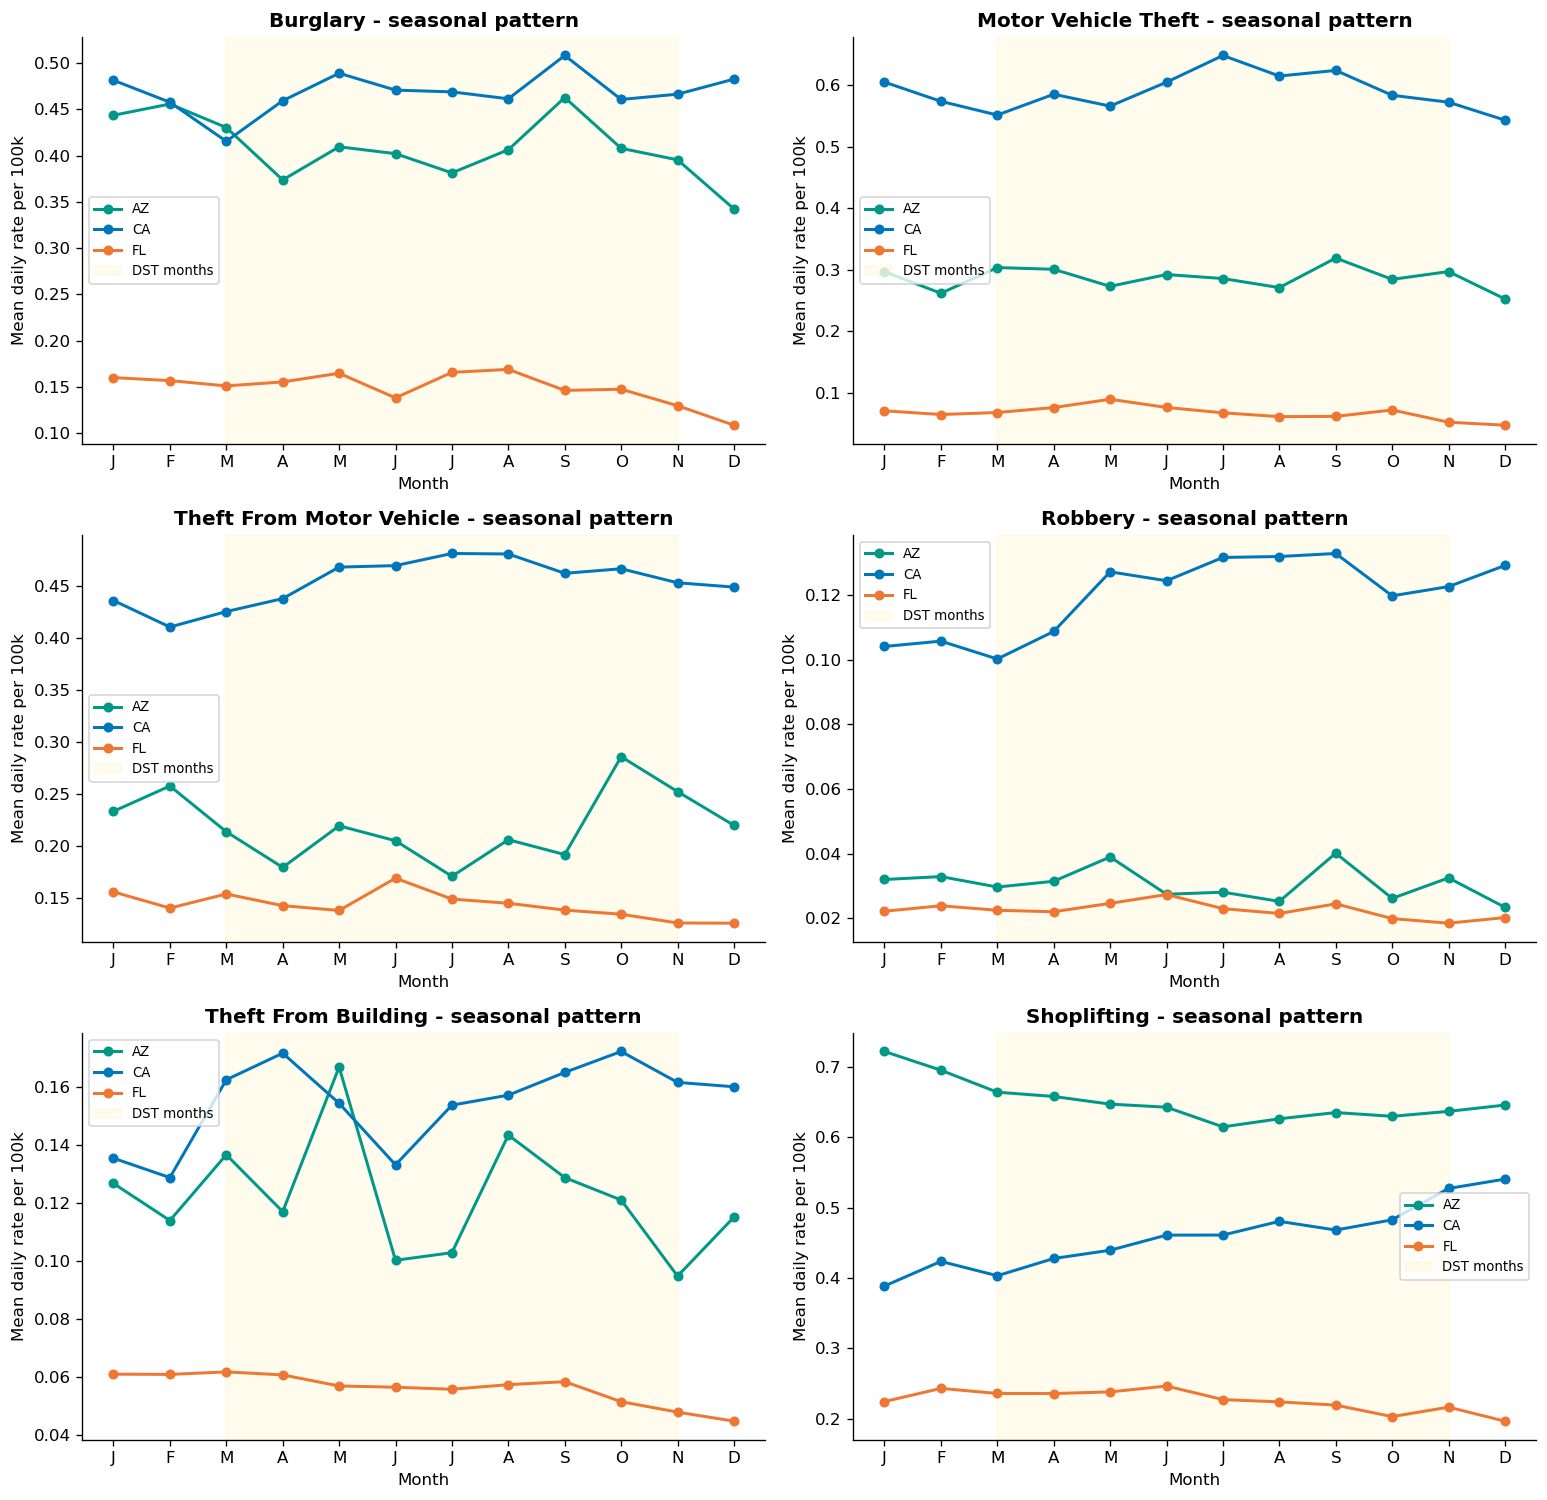

In [52]:
# Seasonal decomposition: is there a simple seasonal driver we might confuse with DST?
# Month-level crime rates in treated vs control, averaged over all 3 years
seasonal = (
    sample
    .groupby(['state', 'month', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k','mean'))
)

n = len(crime_types)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()
state_colors = {'AZ': '#009988', 'CA': '#0077BB', 'FL': '#EE7733'}

for i, ct in enumerate(crime_types):
    ax = axes[i]
    sub = seasonal[seasonal['crime_type'] == ct]
    for st, sdf in sub.groupby('state'):
        ax.plot(sdf['month'], sdf['mean_rate'], 'o-', label=st,
                color=state_colors[st], lw=1.8, ms=5)
    # Shade DST months
    ax.axvspan(3, 11, alpha=0.07, color='gold', label='DST months')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean daily rate per 100k')
    ax.set_title(titles.get(ct, ct.replace('_', ' ').title()) + ' - seasonal pattern', fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 9. Summary

In [53]:
summary_specs = []
for ct in crime_types:
    label_base = titles.get(ct, ct.replace('_', ' ').title())
    summary_specs.extend([
        (f'{ct} | rate | baseline',      f'{label_base}: baseline TWFE'),
        (f'{ct} | rate | + socio',       f'{label_base}: + socio controls'),
        (f'{ct} | log(rate) | baseline', f'{label_base}: log(rate), baseline'),
    ])

rows = []
for key, label in summary_specs:
    if key not in results:
        continue
    r = results[key]
    coef = r.params.get('in_dst_window', float('nan'))
    se   = r.bse.get('in_dst_window', float('nan'))
    pval = r.pvalues.get('in_dst_window', float('nan'))
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    rows.append({
        'Specification': label,
        'coef': round(coef, 5),
        'SE': round(se, 5),
        'sig': stars,
        'p-value': round(pval, 4),
    })

summary_df = pd.DataFrame(rows)
print('=== MAIN RESULTS SUMMARY ===')
print(summary_df.to_string(index=False))
print()
print('FE = county + year-month, SE clustered at county level.')
print('Significance: *** p<0.01, ** p<0.05, * p<0.1')

=== MAIN RESULTS SUMMARY ===
                                Specification    coef     SE sig  p-value
                      Burglary: baseline TWFE  0.0171 0.0097   *   0.0759
                   Burglary: + socio controls  0.0172 0.0097   *   0.0757
                Burglary: log(rate), baseline  0.0055 0.0038       0.1483
           Motor Vehicle Theft: baseline TWFE -0.0154 0.0124       0.2146
        Motor Vehicle Theft: + socio controls -0.0154 0.0124       0.2149
     Motor Vehicle Theft: log(rate), baseline -0.0025 0.0031       0.4255
      Theft From Motor Vehicle: baseline TWFE  0.0160 0.0089   *   0.0725
   Theft From Motor Vehicle: + socio controls  0.0160 0.0089   *   0.0725
Theft From Motor Vehicle: log(rate), baseline  0.0074 0.0039   *   0.0590
                       Robbery: baseline TWFE  0.0058 0.0029  **   0.0467
                    Robbery: + socio controls  0.0058 0.0029  **   0.0467
                 Robbery: log(rate), baseline  0.0035 0.0019   *   0.0595
         

## 9.5 Inference Checks

This section reports concise inference checks without additional multiple-testing corrections:

1. Baseline TWFE estimates ranked by p-value.
2. Joint pre-trend tests for event-study pre-period coefficients.
3. Placebo cutoff tests at a non-DST date (June 15) within narrow windows. (Note: This is distinct from the standard-time window placebo robustness check reported earlier, which tests for effects during the winter months).

In [57]:
# Baseline table ranked by p-value (no multiple-testing adjustment)
baseline_rows = []
for ct in crime_types:
    key = f'{ct} | rate | baseline'
    if key not in results:
        continue
    r = results[key]
    p = float(r.pvalues.get('in_dst_window', np.nan))
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    baseline_rows.append({
        'crime_type': ct,
        'label': titles.get(ct, ct.replace('_', ' ').title()),
        'beta': float(r.params.get('in_dst_window', np.nan)),
        'se': float(r.bse.get('in_dst_window', np.nan)),
        'p_value': p,
        'sig': stars,
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values('p_value').reset_index(drop=True)
print('Baseline TWFE estimates (ranked by p-value):')
print(baseline_df.to_string(index=False))
print('\nSignificance legend: *** p<0.01, ** p<0.05, * p<0.10')

Baseline TWFE estimates (ranked by p-value):
              crime_type                    label    beta     se  p_value sig
                 robbery                  Robbery  0.0058 0.0029   0.0467  **
theft_from_motor_vehicle Theft From Motor Vehicle  0.0160 0.0089   0.0725   *
                burglary                 Burglary  0.0171 0.0097   0.0759   *
     motor_vehicle_theft      Motor Vehicle Theft -0.0154 0.0124   0.2146    
             shoplifting              Shoplifting  0.0142 0.0126   0.2607    
     theft_from_building      Theft From Building -0.0070 0.0074   0.3500    

Significance legend: *** p<0.01, ** p<0.05, * p<0.10


In [58]:
def event_study_joint_pretrend_test(df, outcome, entity='county_fips', time='data_year',
                                    cluster='county_fips', clip=(-8, 8), ref_bin=-1):
    d = df.copy()
    d['week_rel'] = (d['days_from_dst_start'] // 7).clip(*clip)
    bins = [b for b in sorted(d['week_rel'].dropna().unique()) if b != ref_bin]

    dum_cols = []
    pre_cols = []
    for b in bins:
        col = f'tw_{b:+d}'
        d[col] = d['treated_state'].astype(float) * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)
        if b <= -2:
            pre_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res = sm.OLS(d2[outcome], X).fit(cov_type='cluster', cov_kwds={'groups': groups})

    if not pre_cols:
        return np.nan, 0

    hypothesis = ', '.join([f'{c} = 0' for c in pre_cols])
    wald = res.wald_test(hypothesis)
    pval = float(np.asarray(wald.pvalue).reshape(-1)[0])
    return pval, len(pre_cols)


pretrend_rows = []
for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()
    pval, k = event_study_joint_pretrend_test(sub, 'crime_rate_per_100k')
    pretrend_rows.append({
        'crime_type': ct,
        'label': titles.get(ct, ct.replace('_', ' ').title()),
        'n_pre_bins_tested': k,
        'joint_pretrend_p_value': pval,
    })

pretrend_df = pd.DataFrame(pretrend_rows).sort_values('joint_pretrend_p_value')
print('Joint pre-trend tests (H0: all pre-period event-study coefficients = 0):')
print(pretrend_df.to_string(index=False))

Joint pre-trend tests (H0: all pre-period event-study coefficients = 0):
              crime_type                    label  n_pre_bins_tested  joint_pretrend_p_value
                burglary                 Burglary                  7                  0.0173
             shoplifting              Shoplifting                  7                  0.1810
     theft_from_building      Theft From Building                  7                  0.2261
                 robbery                  Robbery                  7                  0.3291
theft_from_motor_vehicle Theft From Motor Vehicle                  7                  0.4402
     motor_vehicle_theft      Motor Vehicle Theft                  7                  0.4535


In [59]:
def placebo_cutoff_test(df, outcome='crime_rate_per_100k', fake_month=6, fake_day=15,
                        window_days=21, entity='county_fips', time='data_year', cluster='county_fips'):
    d = df.copy()

    fake_date = pd.to_datetime(d['data_year'].astype(int).astype(str) + f'-{fake_month:02d}-{fake_day:02d}')
    d['fake_days_from_cutoff'] = (pd.to_datetime(d['incident_date']) - fake_date).dt.days
    d = d[d['fake_days_from_cutoff'].abs() <= window_days].copy()
    d['fake_post_cutoff'] = (d['fake_days_from_cutoff'] >= 0).astype(float)

    if d.empty:
        return np.nan, np.nan, np.nan, 0

    res = run_twfe(
        d,
        outcome=outcome,
        regressors=['fake_post_cutoff', 'is_weekend', 'is_holiday'],
        entity=entity,
        time=time,
        cluster=cluster,
    )
    return (
        float(res.params.get('fake_post_cutoff', np.nan)),
        float(res.bse.get('fake_post_cutoff', np.nan)),
        float(res.pvalues.get('fake_post_cutoff', np.nan)),
        int(res.nobs),
    )


placebo_rows = []
for ct in crime_types:
    sub = sample[sample['crime_type'] == ct].copy()
    b, se, p, n = placebo_cutoff_test(sub, outcome='crime_rate_per_100k')
    placebo_rows.append({
        'crime_type': ct,
        'label': titles.get(ct, ct.replace('_', ' ').title()),
        'placebo_beta': b,
        'placebo_se': se,
        'placebo_p_value': p,
        'n_obs': n,
    })

placebo_df = pd.DataFrame(placebo_rows).sort_values('placebo_p_value')
print('Placebo cutoff test (June 15, +/-21 days, county FE + year FE):')
print(placebo_df.to_string(index=False))

Placebo cutoff test (June 15, +/-21 days, county FE + year FE):
              crime_type                    label  placebo_beta  placebo_se  placebo_p_value  n_obs
                burglary                 Burglary       -0.0202      0.0141           0.1540  17673
theft_from_motor_vehicle Theft From Motor Vehicle        0.0252      0.0229           0.2713  17673
     motor_vehicle_theft      Motor Vehicle Theft        0.0089      0.0096           0.3556  17673
     theft_from_building      Theft From Building        0.0054      0.0076           0.4715  17673
                 robbery                  Robbery        0.0031      0.0051           0.5367  17673
             shoplifting              Shoplifting        0.0041      0.0120           0.7328  17673


## 10. Notes on Interpretation

The coefficient on `in_dst_window` is the estimated change in daily crime rate (per 100,000 residents) during the DST window in CA/FL relative to AZ after removing county and year-month fixed effects.

The current specification is estimated for six offense types: burglary, motor vehicle theft, robbery, shoplifting, theft from building, and theft from motor vehicle.

### Interpretation of the current run
- Baseline estimates are positive for robbery, theft from motor vehicle, and burglary.
- Motor vehicle theft, shoplifting, and theft from building are not statistically distinguishable from zero in baseline TWFE.
- Placebo cutoff tests at a non-DST date (June 15, +/-21 days) are null across all six outcomes, which supports design validity. (Note: This summer cutoff check is distinct from the winter standard-time placebo check, which showed some marginal noise).
- Joint pre-trend tests are mostly non-rejected, but burglary shows a pre-trend rejection (p=0.017), so burglary-specific causal claims should be treated cautiously.

A positive coefficient indicates higher DST-window crime in treated states relative to AZ; a negative coefficient indicates lower DST-window crime in treated states relative to AZ.

### Design limitations
- With six outcomes, some marginally significant findings can arise by chance, so conclusions should emphasize consistency across specifications.
- Offense categories differ in reporting quality and seasonal profile, affecting comparability across outcomes.
- CA/FL and AZ differ in climate and economic activity; fixed effects mitigate but do not fully remove differential seasonality.
- Navajo Nation DST observance in AZ is addressed by excluding affected AZ control counties.

### Reporting guidance
- Present point estimates, confidence intervals, and pre-trend/placebo diagnostics together.
- Emphasize results that are directionally stable across baseline, socioeconomic-control, event-study, and robustness specifications.
- Retain null findings in summary tables to avoid selective inference.

### Recommended extensions
- Evaluate hourly mechanisms for outcomes with the strongest daylight-consistent patterns.
- Add count-model robustness checks (for example, Poisson or negative binomial).
- Consider alternative control constructions (for example, synthetic control variants) for additional identification support.